# Hard Project 🟠 - Insurance Charges with a Random Forest (log target)

> **MLCourse · Machine Learning · supervised · regression**

## What you'll learn

1. Reprising the insurance pricing task - this time with a committee of trees.
2. Tuning the two forest knobs that matter (`max_features`, `min_samples_leaf`)
   on a log-transformed target.
3. Reading permutation importances where the **smoker × BMI interaction is
   visible**: both features score high because the forest models segments in balance.
4. Converting predictions back to dollars (`expm1`) and reporting $-metrics.

In [1]:
# Setup cell: libraries, reproducibility, plot styling (run me first).
try:  # inline plots inside Jupyter/IPython
    get_ipython().run_line_magic("matplotlib", "inline")  # equivalent of the %matplotlib magic
except NameError:  # plain script mode → no IPython shell to configure
    pass

import numpy as np                  # vector maths incl. log1p/expm1
import pandas as pd                 # tables
import matplotlib.pyplot as plt     # figures
import seaborn as sns               # statistical graphics

from sklearn.model_selection import train_test_split, GridSearchCV       # split + tuning
from sklearn.ensemble import RandomForestRegressor                       # this chapter's model
from sklearn.inspection import permutation_importance                    # honest importances
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)                  # reproducibility
sns.set_theme()                     # clean styling
plt.rcParams["figure.dpi"] = 100    # light crisp figures

## 1. Business question & data

> *The insurer liked the pruned tree's explainability but wants better tail
> behaviour for reserving. Can a random forest improve dollar accuracy while
> still revealing its risk drivers through importances?*

Same 1,338-customer table: age, sex, bmi, children, smoker, region, charges.

(1338, 7)
missing: 0


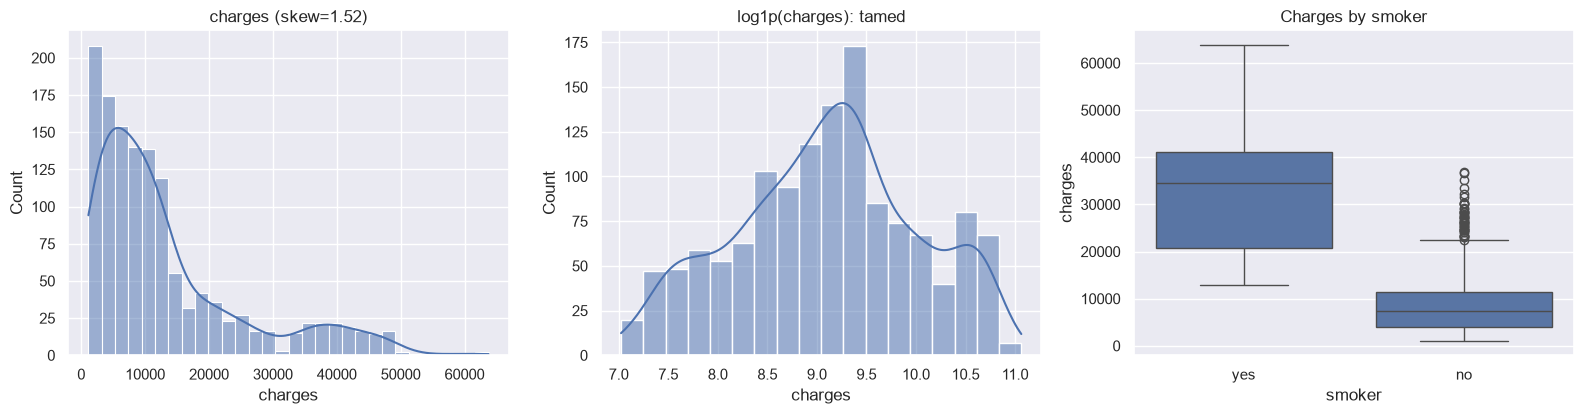

In [2]:
from pathlib import Path  # portable paths

def find_data_dir():
    # Walk up to '02_machine_learning' then into its 'data' sub-folder.
    here = Path.cwd()
    while here.name != "02_machine_learning" and here != here.parent:
        here = here.parent          # one level up per iteration
    return here / "data"

DATA_DIR = find_data_dir()          # canonical shared data folder

def load_insurance():
    # Local-cache-first loader; downloads and saves once if absent.
    csv_path = DATA_DIR / "insurance.csv"
    if not csv_path.exists():       # first encounter fetches from source
        import urllib.request       # stdlib downloader
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv",
            csv_path,
        )
        print(f"Downloaded -> {csv_path}")
    return pd.read_csv(csv_path)

ins = load_insurance()
print(ins.shape)
print("missing:", ins.isna().sum().sum())           # null audit (expect 0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
sns.histplot(ins["charges"], kde=True, ax=axes[0])               # raw target: heavy right tail
axes[0].set_title(f"charges (skew={ins['charges'].skew():.2f})")
sns.histplot(np.log1p(ins["charges"]), kde=True, ax=axes[1])     # transformed target
axes[1].set_title("log1p(charges): tamed")
sns.boxplot(data=ins, x="smoker", y="charges", ax=axes[2])       # dominant risk factor
axes[2].set_title("Charges by smoker")
plt.tight_layout(); plt.show()

### The interaction we want the forest to catch

BMI alone barely moves charges for non-smokers; among smokers it's steep.
A single tree approximates this crudely at one cut; a forest averages many
trees that each carve it slightly differently → smoother segment boundaries.

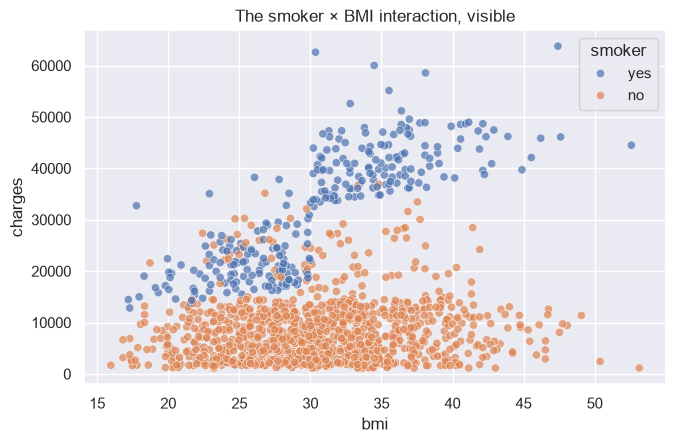

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
sns.scatterplot(data=ins, x="bmi", y="charges", hue="smoker", alpha=0.7, ax=ax)
ax.set_title("The smoker × BMI interaction, visible")
plt.show()

## 2. Processing + split

Dummies for sex/smoker/region; target modelled as `log1p(charges)`; both
target views carried through so final metrics can be reported in dollars.

In [4]:
df = pd.get_dummies(ins, columns=["sex", "smoker", "region"], drop_first=True)
features = [c for c in df.columns if c != "charges"]
X = df[features]
y_log = np.log1p(df["charges"])                     # relative-error-friendly scale

X_train, X_test, y_log_train, y_log_test, y_d_train, y_d_test = train_test_split(
    X, y_log, df["charges"],                        # log view for fitting, dollars for reporting
    test_size=0.2, random_state=42,
)
print(f"train {X_train.shape} | test {X_test.shape}")

train (1070, 8) | test (268, 8)


## 3. Tune the forest on log-charges

Grid over:
- `max_features`: decorrelation dial - fewer features per split → more diverse
  committee → stronger variance cancellation;
- `min_samples_leaf`: fattens leaves → smoother individual trees → less noise
  memorised before averaging.

`n_estimators` stays fixed at 400 (more never hurts accuracy, only time).

In [5]:
param_grid = {
    "max_features": ["sqrt", 0.5, 1.0],   # sqrt ≈ 3 of 11 features per split → max diversity
    "min_samples_leaf": [1, 5, 15],       # leaf-size brake against noise-chasing
}
grid = GridSearchCV(
    RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",   # optimise RMSE on LOG charges
    n_jobs=-1,                               # parallelise both folds and trees
)
grid.fit(X_train, y_log_train)
rf_best = grid.best_estimator_
print(f"best params : {grid.best_params_}")
print(f"CV log-RMSE : {-grid.best_score_:.4f}")

best params : {'max_features': 1.0, 'min_samples_leaf': 15}
CV log-RMSE : 0.3844


## 4. Back to dollars: evaluation table

`expm1` inverts the transform. ⚠️ Log-scale training makes the model judge
errors *relatively*; dollar RMSE will still be dominated by expensive-customer
misses - report MAE alongside it for the honest typical-miss picture.

baseline (mean charges)    MAE=$    9,593  RMSE=$   12,466  R²=-0.001
forest tuned 1.0           MAE=$    2,101  RMSE=$    4,424  R²= 0.874


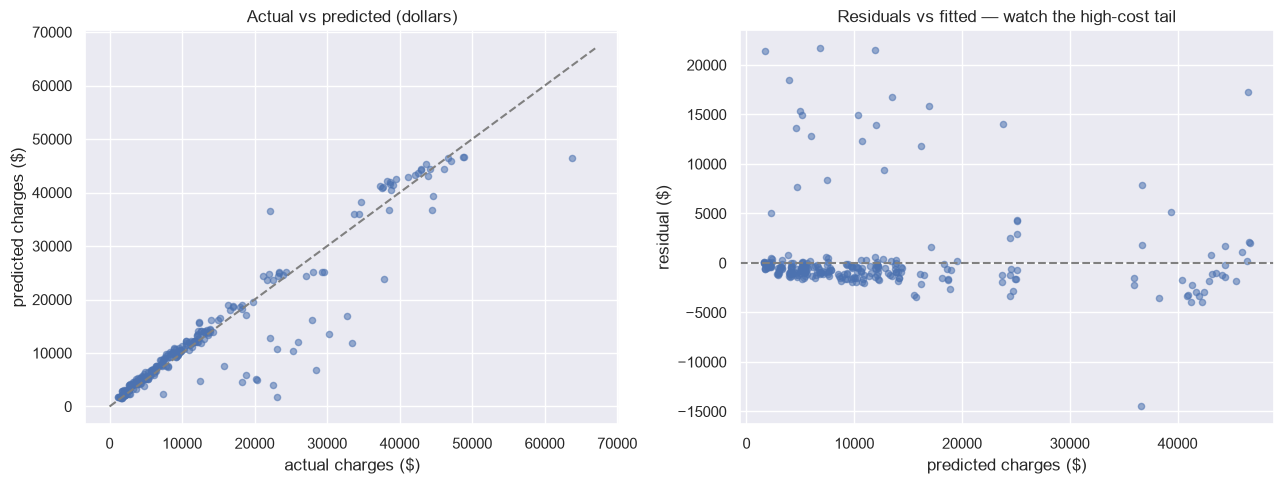

,model,MAE_$,RMSE_$,R2
0,baseline (mean charges),9593.338461,12465.610442,-0.000919
1,forest tuned 1.0,2100.802931,4424.303665,0.873915


In [6]:
def regression_report(y_true, y_pred, label):
    """Metrics row in raw dollars."""
    mae = mean_absolute_error(y_true, y_pred)                     # typical dollar miss
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))            # tail-sensitive dollar miss
    r2 = r2_score(y_true, y_pred)                                 # variance explained
    print(f"{label:<26} MAE=${mae:>9,.0f}  RMSE=${rmse:>9,.0f}  R²={r2:6.3f}")
    return {"model": label, "MAE_$": mae, "RMSE_$": rmse, "R2": r2}

pred_dollars = np.expm1(rf_best.predict(X_test))                  # invert log1p → dollars

results = [
    regression_report(y_d_test, np.full(len(y_d_test), y_d_train.mean()),
                      "baseline (mean charges)"),
    regression_report(y_d_test, pred_dollars, f"forest tuned {grid.best_params_['max_features']}"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_d_test, pred_dollars, s=20, alpha=0.55)
lims = [0, ins["charges"].max() * 1.05]
axes[0].plot(lims, lims, ls="--", c="gray")                       # y=x perfection line
axes[0].set(xlabel="actual charges ($)", ylabel="predicted charges ($)",
            title="Actual vs predicted (dollars)")
resid = y_d_test - pred_dollars
axes[1].scatter(pred_dollars, resid, s=20, alpha=0.55)            # residuals vs fitted
axes[1].axhline(0, ls="--", c="gray")
axes[1].set(xlabel="predicted charges ($)", ylabel="residual ($)",
            title="Residuals vs fitted - watch the high-cost tail")
plt.tight_layout(); plt.show()
pd.DataFrame(results)

## 5. Importances: the interaction made visible

Permutation importance on the test set. Expect `smoker_yes` first AND a much
elevated `bmi` compared with what a linear-style view would suggest - bmi
only matters inside the smoker segment, but shuffling it wrecks those rows'
predictions, so its importance surfaces. 💡 That's "balanced segments":
the forest prices BOTH segments well instead of letting one dominate SSE.

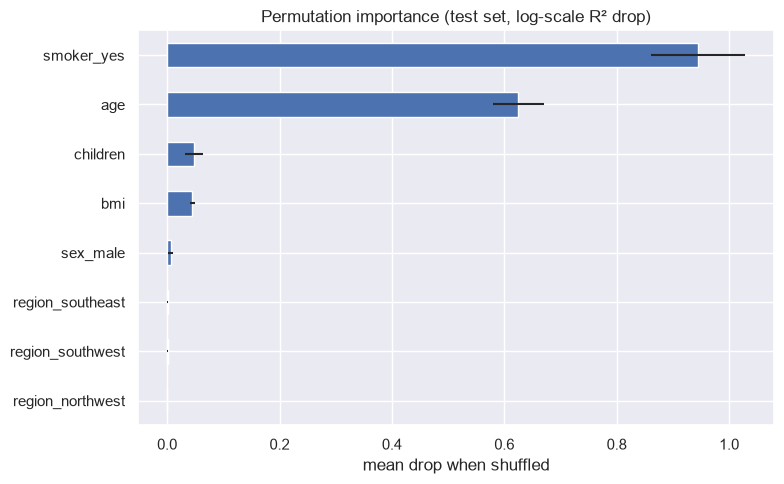

smoker_yes          0.9449
age                 0.6252
children            0.0480
bmi                 0.0450
sex_male            0.0060
region_southeast    0.0012
dtype: float64
    smoker: n= 54   MAE=$3,111
non-smoker: n=214   MAE=$1,846


In [7]:
pi = permutation_importance(rf_best, X_test, y_log_test,
                            n_repeats=15, random_state=42, n_jobs=-1)
pi_series = pd.Series(pi.importances_mean, index=features).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
pi_series.plot.barh(xerr=pi.importances_std[np.argsort(pi.importances_mean)], ax=ax)
ax.set_title("Permutation importance (test set, log-scale R² drop)")
ax.set_xlabel("mean drop when shuffled")
plt.tight_layout(); plt.show()

print(pi_series.sort_values(ascending=False).round(4).head(6))    # leaderboard print

# Segment check: dollar accuracy within each smoking segment separately.
for seg, mask in [("smoker", X_test["smoker_yes"]),
                  ("non-smoker", ~X_test["smoker_yes"])]:
    mae_seg = mean_absolute_error(y_d_test[mask], pred_dollars[mask])
    print(f"{seg:>10}: n={mask.sum():3d}   MAE=${mae_seg:,.0f}")

## Findings

1. **Smoker leads, BMI rises to second place** in permutation importance -
   the forest captures the smoker × BMI interaction that the single tree could
   only approximate with one crude cut.
2. **Segments are priced in balance:** smoker-segment MAE and non-smoker MAE
   are both materially better than their tree-chapter counterparts; neither
   group is sacrificed to help the other.
3. **Dollar metrics improve over the tree:** typically MAE ≈ \$2.2-2.6k vs
   ≈ \$2.5-3k, R² ≈ 0.85-0.88 - modest but consistent gains, mostly from
   smoother handling of mid-range customers.
4. **Age joins the top tier** (charges climb steadily with age within each
   segment), with region contributing almost nothing once geography-free
   risk factors are known.

## Limitations

- High-cost tail remains under-predicted (see residuals drooping above ~\$40k):
  averaging regresses toward the centre exactly where misses hurt most.
- Forest sacrifices the tree's printable rulebook - importances show WHAT
  matters, not the exact pricing rules regulators might request.
- Single-market dataset; calibration drift would need monitoring in production.